# Notebook 3 — Global Trends & Evolution

In this notebook, we take a step back from the 1990s and look at the bigger picture.
The goal is to understand how Netflix content has changed over time across:

- content volume
- genre evolution
- movie duration trends
- country contributions
- movies vs TV shows

We’ll use the cleaned dataset and the helper functions from the `scripts/` folder
to keep the notebook tidy and focused on insights.

# Imports & Setup

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure project root is set
project_root = os.path.abspath("..")

# Add project root to Python path
sys.path.insert(0, project_root)

visuals_dir = os.path.join(project_root, "visuals")
os.makedirs(visuals_dir, exist_ok=True)

def save_visual(filename):
    return os.path.join(visuals_dir, filename)

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from scripts.eda_utils import (
    filter_movies,
    filter_tv_shows,
    movies_per_year,
    top_genres,
    avg_duration_by_genre,
    country_counts
)

from scripts.visualization_utils import (
    plot_movies_per_year,
    plot_top_genres,
    plot_avg_duration,
    plot_avg_duration_by_decade,
    plot_country_counts,
    plot_duration_distribution
)

# Load Cleaned Dataset

In [5]:
cleaned_path = os.path.join(project_root, "data", "processed", "netflix_cleaned.csv")

df = pd.read_csv(cleaned_path)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre,year_added,duration_type,decade
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,93,After a devastating earthquake hits Mexico Cit...,Dramas,2016.0,min,2010
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,78,"When an army recruit is found dead, his fellow...",Horror Movies,2018.0,min,2010
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action,2017.0,min,2000
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,123,A brilliant group of students become card-coun...,Dramas,2020.0,min,2000
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,1,A genetics professor experiments with a treatm...,International TV,2017.0,Seasons,2010


# Split into Movies and TV Shows

In [6]:
movies_df = filter_movies(df)
tv_df = filter_tv_shows(df)

movies_df.head(), tv_df.head()


(  show_id   type  title           director  \
 0      s2  Movie   7:19  Jorge Michel Grau   
 1      s3  Movie  23:59       Gilbert Chan   
 2      s4  Movie      9        Shane Acker   
 3      s5  Movie     21     Robert Luketic   
 5      s7  Movie    122    Yasir Al Yasiri   
 
                                                 cast        country  \
 0  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
 1  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
 2  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
 3  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   
 5  Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...          Egypt   
 
    date_added  release_year  duration  \
 0  2016-12-23          2016        93   
 1  2018-12-20          2011        78   
 2  2017-11-16          2009        80   
 3  2020-01-01          2008       123   
 5  2020-06-01          2019        95   
 
                            

### Notes
- Some analyses apply only to movies (because of duration).
- Others apply to both movies and TV shows.

# Content Growth Over Time

In [7]:
movies_by_year = movies_per_year(movies_df)
movies_by_year.head()

,release_year,count
0,1942,1
1,1944,1
2,1945,1
3,1946,1
4,1947,1


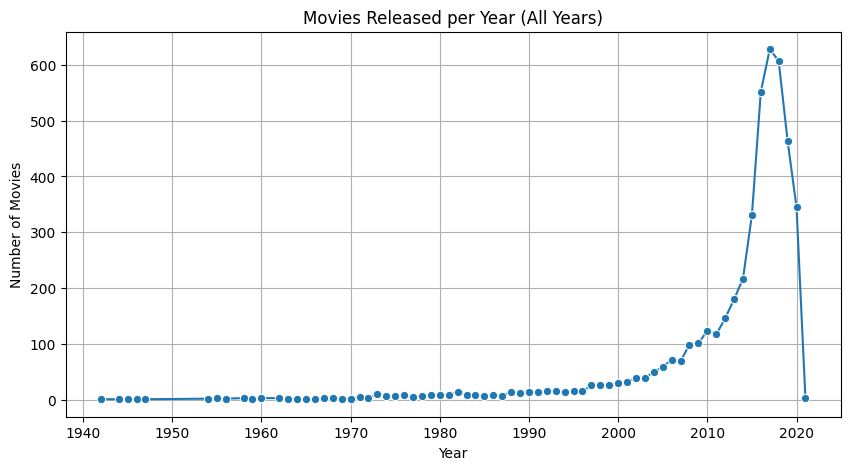

In [15]:
plot_movies_per_year(
    movies_by_year,
    title="Movies Released per Year (All Years)",
    save_path=save_visual("movies_per_year_all_years.png")
)

# TV shows per year

In [8]:
tv_by_year = (
    tv_df.groupby("release_year")
         .size()
         .reset_index(name="count")
         .sort_values("release_year")
)

tv_by_year.head()


,release_year,count
0,1990,1
1,2001,1
2,2006,3
3,2010,1
4,2011,2


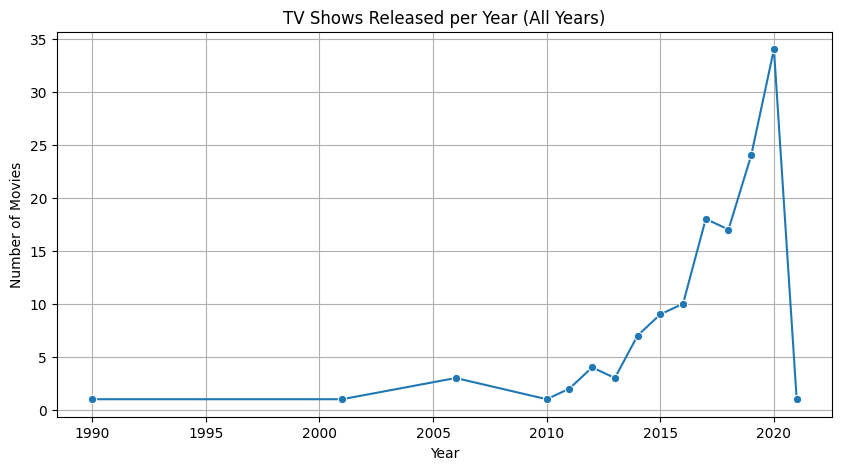

In [9]:
plot_movies_per_year(
    tv_by_year,
    title="TV Shows Released per Year (All Years)",
    save_path=save_visual("tv_shows_per_year_all_years.png")
)

# Genre Trends

## Top genres overall (movies)

In [10]:
top_genres_overall = top_genres(movies_df, n=10)
top_genres_overall

,genre,count
0,Dramas,1343
1,Comedies,1029
2,Action,696
3,Children,421
4,Documentaries,352
5,Stand-Up,276
6,Horror Movies,239
7,International Movies,100
8,Classic Movies,69
9,Thrillers,49


c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="count", y="genre", palette="viridis")


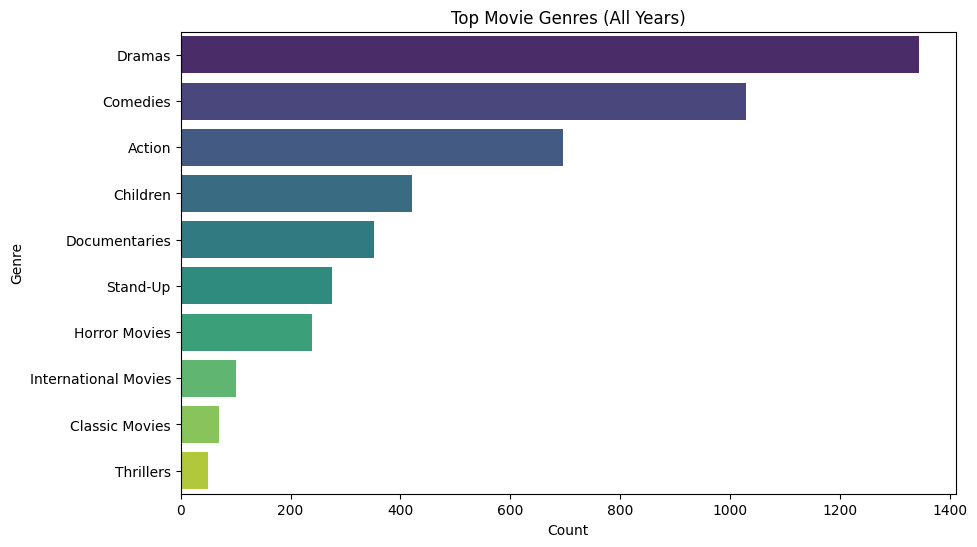

In [11]:
plot_top_genres(
    top_genres_overall,
    title="Top Movie Genres (All Years)",
    save_path=save_visual("top_genres_all_years.png")
)

# Top genres in recent years (2010+)

In [12]:
recent_movies = movies_df[movies_df["release_year"] >= 2010]
recent_genres = top_genres(recent_movies, n=10)
recent_genres

,genre,count
0,Dramas,1118
1,Comedies,802
2,Action,468
3,Documentaries,332
4,Children,328
5,Stand-Up,251
6,Horror Movies,207
7,International Movies,86
8,Thrillers,39
9,Uncategorized,21


c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="count", y="genre", palette="viridis")


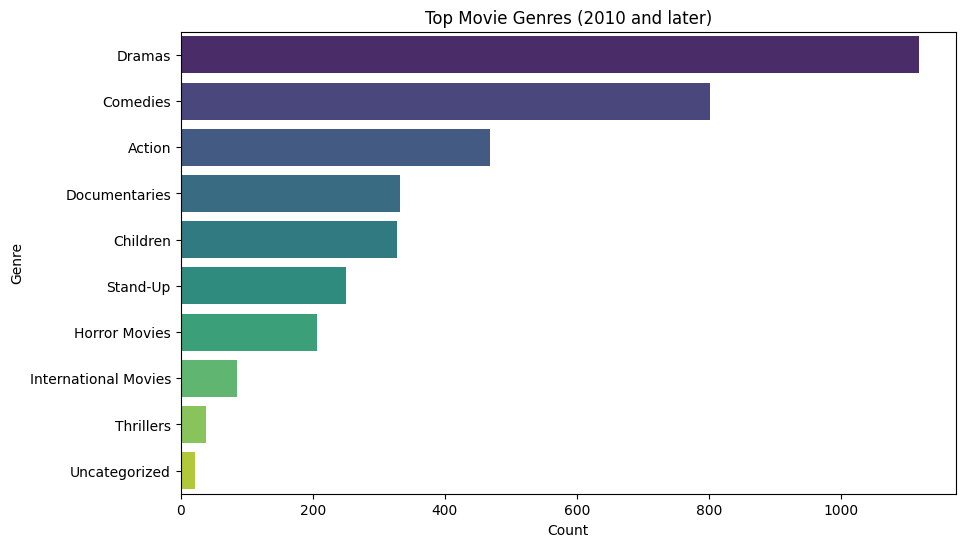

In [13]:
plot_top_genres(
    recent_genres,
    title="Top Movie Genres (2010 and later)",
    save_path=save_visual("top_genres_2010_plus.png")
)

# Duration Trends Over Time

## Average duration by decade

In [15]:
duration_by_decade = (
    movies_df.groupby("decade")["duration"]
             .mean()
             .reset_index()
             .sort_values("decade")
)

duration_by_decade


,decade,duration
0,1940,51.400000
1,1950,107.090909
2,1960,144.250000
3,1970,119.083333
4,1980,113.557895
5,1990,115.120219
6,2000,113.424448
7,2010,99.797980
8,2020,94.270115


c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="decade", y="duration", palette="viridis")


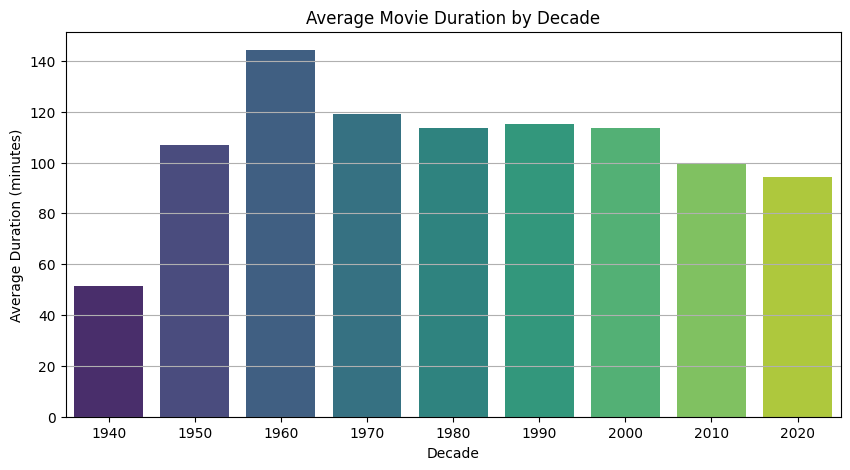

In [16]:
plot_avg_duration_by_decade(
    duration_by_decade.rename(columns={"duration": "duration"}),
    title="Average Movie Duration by Decade",
    save_path=save_visual("avg_duration_by_decade.png")
)

# Duration distribution (all movies)

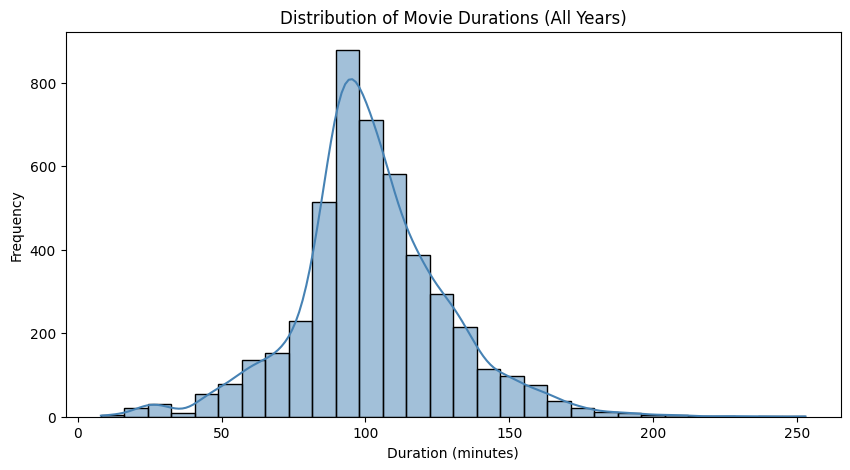

In [17]:
plot_duration_distribution(
    movies_df,
    title="Distribution of Movie Durations (All Years)",
    save_path=save_visual("duration_distribution_all_years.png")
)

# Country Contributions Over Time

## Top countries overall

In [18]:
top_countries_overall = country_counts(movies_df, n=10)
top_countries_overall

,country,count
0,United States,1856
1,India,858
2,United Kingdom,289
3,Canada,151
4,France,129
5,Spain,105
6,Egypt,91
7,Turkey,76
8,Philippines,74
9,Indonesia,73


c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="count", y="country", palette="cubehelix")


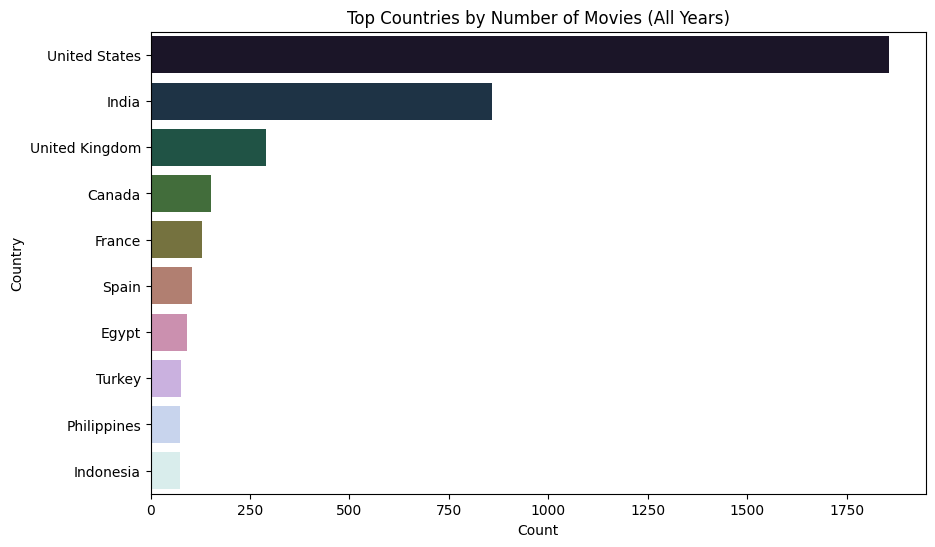

In [20]:
plot_country_counts(
    top_countries_overall,
    title="Top Countries by Number of Movies (All Years)",
    save_path=save_visual("top_countries_all_years.png")
)

# Older vs newer periods

In [21]:
older = movies_df[movies_df["release_year"] < 2010]
newer = movies_df[movies_df["release_year"] >= 2010]

top_countries_older = country_counts(older, n=10)
top_countries_newer = country_counts(newer, n=10)

top_countries_older, top_countries_newer

(          country  count
 0   United States    453
 1           India    239
 2  United Kingdom     51
 3       Hong Kong     44
 4           Egypt     31
 5         Germany     15
 6           Japan     14
 7          France     13
 8        Thailand      9
 9       Indonesia      9,
           country  count
 0   United States   1403
 1           India    619
 2  United Kingdom    238
 3          Canada    143
 4          France    116
 5           Spain    103
 6          Turkey     68
 7     Philippines     68
 8          Mexico     66
 9       Indonesia     64)

# Movies vs TV Shows Over Time

## Combine counts per year

In [22]:
movies_by_year["type"] = "Movie"
tv_by_year["type"] = "TV Show"

combined = pd.concat([movies_by_year, tv_by_year], ignore_index=True)
combined.head()

,release_year,count,type
0,1942,1,Movie
1,1944,1,Movie
2,1945,1,Movie
3,1946,1,Movie
4,1947,1,Movie


# Plot comparison

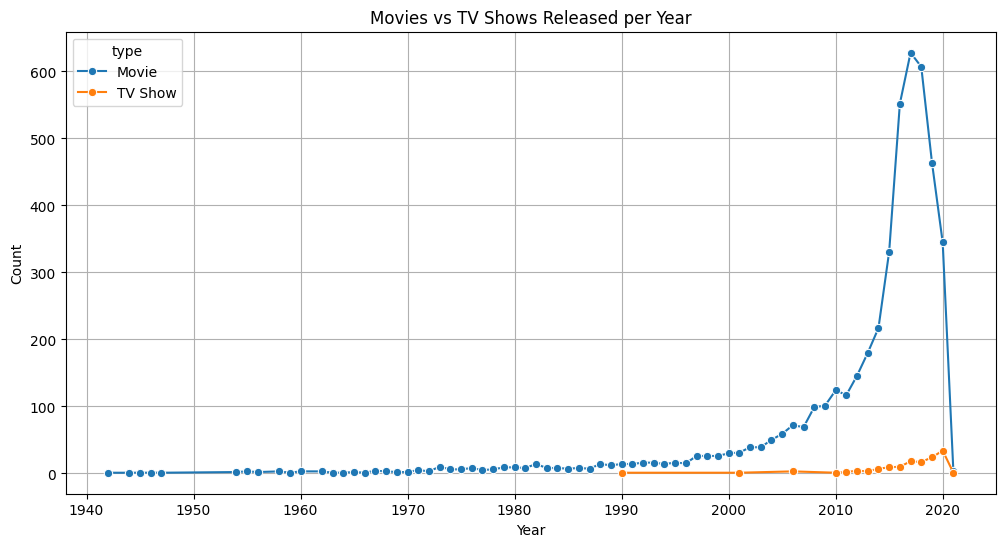

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=combined, x="release_year", y="count", hue="type", marker="o")
plt.title("Movies vs TV Shows Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.savefig(save_visual("movies_vs_tv_per_year.png"), bbox_inches="tight")
plt.show()

# Summary of Global Trends

### Key Global Trends Observed

- Content volume has increased significantly over time, especially in recent years.
- Certain genres dominate overall, but newer years show shifts in popularity.
- Average movie duration changes across decades, suggesting evolving storytelling styles.
- A few countries contribute a large share of the catalog, though diversity increases in later years.
- TV shows have grown rapidly compared to earlier periods, especially after 2010.

Together with the 1990s deep dive, these insights give a complete picture of how Netflix content has evolved.